## Modelo de aprendizagem não supervisionada: clusterização e PCA

Objetivo deste notebook:

- **Aplicar técnicas de aprendizagem não supervisionada** aos dados de voos.
- **Clusterizar rotas/companhias/aeroportos** para identificar grupos com perfis semelhantes.
- **Aplicar PCA (análise de componentes principais)** para reduzir dimensionalidade e visualizar a estrutura dos dados.
- **Interpretar criticamente os resultados**, discutindo limitações e próximos passos.

Os dados e funções de limpeza são consistentes com os notebooks de EDA e de classificação supervisionada (`flights.csv`, `airports.csv`, `airlines.csv`).

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

np.random.seed(42)

In [4]:
# Funções de carregamento e limpeza — reutilizadas do EDA

CANDIDATE_DIRS = [Path("."), Path("data")]


def pick_path(filename: str) -> Path:
    for d in CANDIDATE_DIRS:
        p = d / filename
        if p.exists():
            return p
    return CANDIDATE_DIRS[0] / filename


FLIGHTS_PATH = pick_path("flights.csv")
AIRPORTS_PATH = pick_path("airports.csv")
AIRLINES_PATH = pick_path("airlines.csv")

assert FLIGHTS_PATH.exists(), f"Arquivo não encontrado: {FLIGHTS_PATH.resolve()}"

DELAY_CAUSE_COLS = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY",
]


def hhmm_to_minutes(x: object) -> float:
    """Converte HHMM (ex: 5, '0005', 2354) em minutos desde 00:00.

    Retorna NaN quando não for possível converter.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan

    s = str(x).strip()
    if s == "" or s.lower() in {"nan", "none"}:
        return np.nan

    s = s.zfill(4)
    if not s.isdigit() or len(s) != 4:
        return np.nan

    hh = int(s[:2])
    mm = int(s[2:])
    if not (0 <= hh <= 23 and 0 <= mm <= 59):
        return np.nan
    return hh * 60 + mm


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["scheduled_dep_min"] = df["SCHEDULED_DEPARTURE"].map(hhmm_to_minutes)
    df["scheduled_dep_hour"] = (df["scheduled_dep_min"] // 60).astype("Int64")

    df["scheduled_arr_min"] = df["SCHEDULED_ARRIVAL"].map(hhmm_to_minutes)
    df["scheduled_arr_hour"] = (df["scheduled_arr_min"] // 60).astype("Int64")
    return df


def clean_flights(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    obj_cols = df.select_dtypes(include=["object", "string"]).columns
    if len(obj_cols) > 0:
        df[obj_cols] = df[obj_cols].replace({"": pd.NA})

    for c in ["CANCELLED", "DIVERTED"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype("Int8")

    not_cancelled = (df["CANCELLED"] == 0) if "CANCELLED" in df.columns else pd.Series(True, index=df.index)

    present_delay_cols = [c for c in DELAY_CAUSE_COLS if c in df.columns]
    if present_delay_cols:
        df.loc[not_cancelled, present_delay_cols] = df.loc[not_cancelled, present_delay_cols].apply(
            pd.to_numeric, errors="coerce"
        ).fillna(0)

    if "CANCELLATION_REASON" in df.columns and "CANCELLED" in df.columns:
        df.loc[not_cancelled & df["CANCELLATION_REASON"].isna(), "CANCELLATION_REASON"] = "NOT_CANCELLED"
        df.loc[(~not_cancelled) & df["CANCELLATION_REASON"].isna(), "CANCELLATION_REASON"] = "UNKNOWN"

    num_like = [
        "YEAR",
        "MONTH",
        "DAY",
        "DAY_OF_WEEK",
        "DISTANCE",
        "DEPARTURE_DELAY",
        "ARRIVAL_DELAY",
        "TAXI_OUT",
        "TAXI_IN",
        "AIR_TIME",
        "ELAPSED_TIME",
        "SCHEDULED_TIME",
    ]
    for c in [x for x in num_like if x in df.columns]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if all(c in df.columns for c in ["YEAR", "MONTH", "DAY"]):
        df["date"] = pd.to_datetime(
            {"year": df["YEAR"], "month": df["MONTH"], "day": df["DAY"]}, errors="coerce"
        )

    df = add_time_features(df)
    return df


def load_sample(
    path: Path,
    chunksize: int = 250_000,
    frac_per_chunk: float = 0.03,
    max_rows: int = 400_000,
    seed: int = 42,
) -> pd.DataFrame:
    """Amostra aproximada do CSV (boa para gráficos/modelos sem estourar memória)."""
    rng = np.random.default_rng(seed)
    samples: list[pd.DataFrame] = []

    for chunk in pd.read_csv(path, chunksize=chunksize):
        s = chunk.sample(frac=frac_per_chunk, random_state=int(rng.integers(0, 2**31 - 1)))
        samples.append(s)
        if sum(len(x) for x in samples) >= max_rows:
            break

    df = pd.concat(samples, ignore_index=True)
    if len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=seed).reset_index(drop=True)

    return clean_flights(df)

In [5]:
# Carregar amostra de voos e definir target binário de atraso (para análise, não para treino supervisionado)

df = load_sample(FLIGHTS_PATH)
print("Shape bruto:", df.shape)

mask_ok = (df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)
df_ok = df.loc[mask_ok].copy()

MIN_DELAY_MINUTES = 15
if "ARRIVAL_DELAY" in df_ok.columns:
    df_ok["atrasado"] = (df_ok["ARRIVAL_DELAY"] > MIN_DELAY_MINUTES).astype(int)
    print("Proporção de voos atrasados (target=1):", round(float(df_ok["atrasado"].mean()), 3))

print("Voos considerados (não cancelados/desviados):", df_ok.shape)

Shape bruto: (174572, 36)
Proporção de voos atrasados (target=1): 0.18
Voos considerados (não cancelados/desviados): (171393, 37)


### Abordagem 1: clusterização de rotas/companhias

Nesta seção vamos aplicar **K-Means** para agrupar voos com base em:

- **Companhia aérea (`AIRLINE`)**
- **Aeroporto de origem (`ORIGIN_AIRPORT`)**
- **Aeroporto de destino (`DESTINATION_AIRPORT`)**
- **Distância do voo (`DISTANCE`)**
- **Horário programado de partida (`scheduled_dep_hour`)**

Passos:

1. Selecionar apenas voos realizados (`df_ok`).
2. Criar um subconjunto com essas variáveis.
3. One-hot encoding para variáveis categóricas + padronização das numéricas.
4. Usar o **método do cotovelo** para escolher um `k` razoável.
5. Ajustar o K-Means e **visualizar os clusters** em 2D (via PCA) e em tabelas/resumos.

In [6]:
# Preparar dados para clusterização de rotas

ROUTE_FEATURES_CAT = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
ROUTE_FEATURES_NUM = ["DISTANCE", "scheduled_dep_hour"]

for c in ROUTE_FEATURES_CAT + ROUTE_FEATURES_NUM:
    if c not in df_ok.columns:
        raise ValueError(f"Coluna ausente para clusterização de rotas: {c}")

routes_df = df_ok[ROUTE_FEATURES_CAT + ROUTE_FEATURES_NUM].dropna().copy()

# garantir que categóricas sejam string
for c in ROUTE_FEATURES_CAT:
    routes_df[c] = routes_df[c].astype(str)

n_sample = min(25_000, len(routes_df))
routes_sample = routes_df.sample(n=n_sample, random_state=42)
print("Amostra para clusterização de rotas:", routes_sample.shape)

preprocess_routes = ColumnTransformer(
    [
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False),
            ROUTE_FEATURES_CAT,
        ),
        ("num", StandardScaler(), ROUTE_FEATURES_NUM),
    ]
)

X_routes = preprocess_routes.fit_transform(routes_sample)
print("Matriz de features para K-Means:", X_routes.shape)

Amostra para clusterização de rotas: (25000, 5)
Matriz de features para K-Means: (25000, 1031)


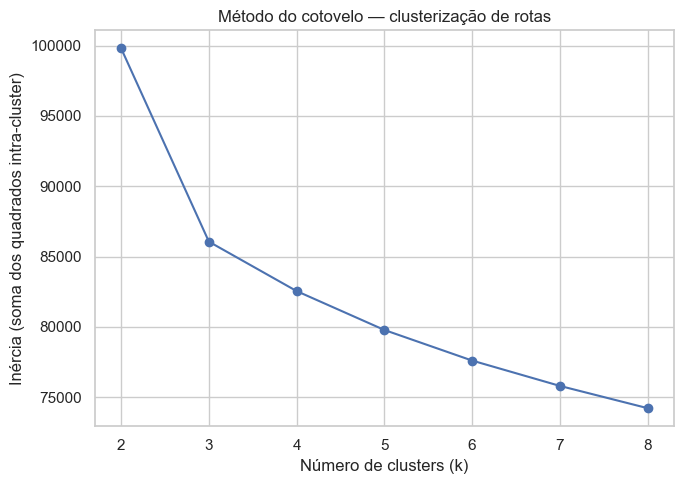

[99802.12880725643,
 86057.58645221857,
 82543.06561473908,
 79776.88354099385,
 77601.03153947869,
 75799.8989369575,
 74216.37186991578]

In [7]:
# Método do cotovelo para escolher k

ks = range(2, 9)
inertias = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_routes)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.plot(list(ks), inertias, marker="o")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Inércia (soma dos quadrados intra-cluster)")
ax.set_title("Método do cotovelo — clusterização de rotas")
plt.tight_layout()
plt.show()

inertias

Variância explicada pelos 2 componentes da PCA (rotas): [0.21761072 0.2091269 ]


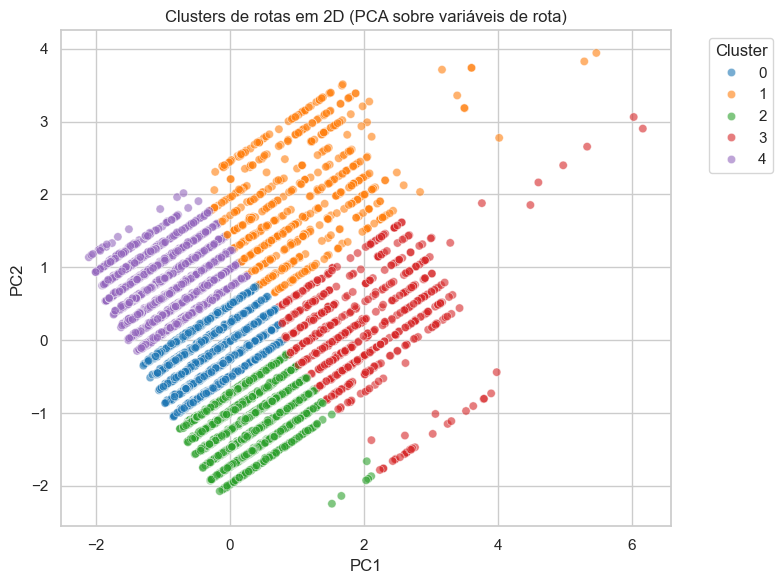

In [8]:
# Ajustar K-Means para um k escolhido (ex.: 5) e projetar em 2D com PCA

best_k = 5  # ajuste este valor se o "cotovelo" sugerir outro k

kmeans_routes = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_routes.fit_predict(X_routes)

pca_2d = PCA(n_components=2, random_state=42)
X_routes_pca = pca_2d.fit_transform(X_routes)

routes_plot = routes_sample.copy()
routes_plot["cluster"] = cluster_labels
routes_plot["PC1"] = X_routes_pca[:, 0]
routes_plot["PC2"] = X_routes_pca[:, 1]

print("Variância explicada pelos 2 componentes da PCA (rotas):", pca_2d.explained_variance_ratio_)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.scatterplot(
    data=routes_plot.sample(n=min(8_000, len(routes_plot)), random_state=42),
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab10",
    alpha=0.6,
    ax=ax,
)
ax.set_title("Clusters de rotas em 2D (PCA sobre variáveis de rota)")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [9]:
# Resumo numérico dos clusters de rotas

cluster_summary = (
    routes_plot
    .groupby("cluster")
    .agg(
        n_voos=("cluster", "size"),
        dist_media=("DISTANCE", "mean"),
        hora_media=("scheduled_dep_hour", "mean"),
        n_companhias=("AIRLINE", "nunique"),
        n_origens=("ORIGIN_AIRPORT", "nunique"),
        n_destinos=("DESTINATION_AIRPORT", "nunique"),
    )
    .sort_values("n_voos", ascending=False)
)

cluster_summary

,n_voos,dist_media,hora_media,n_companhias,n_origens,n_destinos
cluster,,,,,,
4,7136,575.307455,18.422225,14,360,415
2,6978,600.076956,7.692175,14,418,343
0,6444,593.371043,12.993327,14,399,401
3,2511,1888.411788,8.950617,13,130,131
1,1931,1938.723459,17.96116,13,117,122


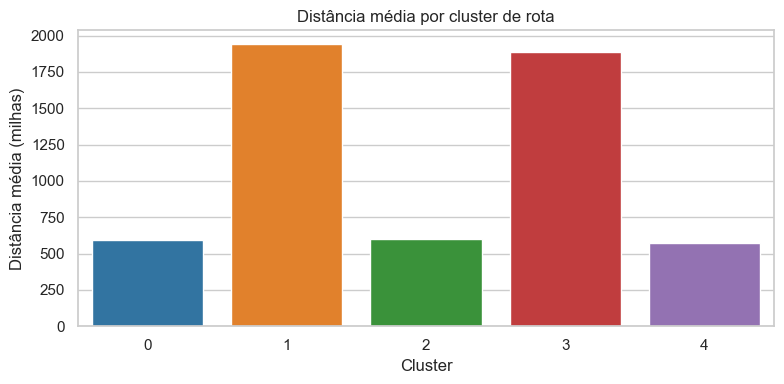

In [13]:
# Distância média por cluster de rota

cluster_summary_plot = cluster_summary.reset_index()

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
sns.barplot(data=cluster_summary_plot, x="cluster", y="dist_media", palette="tab10", ax=ax)
ax.set_xlabel("Cluster")
ax.set_ylabel("Distância média (milhas)")
ax.set_title("Distância média por cluster de rota")
plt.tight_layout()
plt.show()

#### Interpretação dos clusters de rotas (exemplo de leitura)

Ao rodar as células acima, observe:

- **Formato do gráfico de cotovelo**: escolha um `k` onde a redução da inércia começa a diminuir (ponto de "cotovelo").
- **Gráfico PCA 2D**:
  - Clusters bem separados sugerem **grupos de rotas com padrões distintos**.
  - Sobreposição forte indica que as variáveis usadas **não separam tão bem** os grupos de voos.
- **Tabela `cluster_summary`**:
  - Clusters com **distância média maior** tendem a representar **rotas de longa distância**.
  - Diferenças em `hora_media` podem indicar **janelas de horário típicas** (ex.: voos noturnos vs. diurnos).
  - Números de companhias/aeroportos por cluster ajudam a identificar grupos como:
    - "cluster concentrado em poucas rotas/companhias" (rotas de nicho ou hubs específicos);
    - "cluster muito diverso" (rotas mais pulverizadas).

Essas leituras permitem **descrever o perfil de cada cluster**, por exemplo:

- Cluster 0: voos de curta distância, muitos aeroportos diferentes, horários concentrados pela manhã.
- Cluster 1: voos longos saindo de poucos hubs, forte concentração em determinadas companhias.

Os detalhes exatos vão depender dos resultados que aparecem ao executar o notebook.

### Abordagem 2: redução de dimensionalidade com PCA

Agora vamos aplicar **PCA (Principal Component Analysis)** em variáveis numéricas relacionadas ao voo para:

- **Reduzir a dimensionalidade** para 2 componentes principais.
- **Visualizar a distribuição dos voos** nesse espaço 2D.
- Colorir os pontos de acordo com o **atraso real na chegada** (`atrasado`), para ver se há regiões do espaço onde atrasos são mais frequentes.

Variáveis usadas no PCA (todas disponíveis *antes* do voo acontecer):

- `MONTH`, `DAY_OF_WEEK`
- `DISTANCE`
- `SCHEDULED_TIME`
- `scheduled_dep_hour`

In [11]:
# Preparar dados numéricos para PCA

PCA_FEATURES_NUM = ["MONTH", "DAY_OF_WEEK", "DISTANCE", "SCHEDULED_TIME", "scheduled_dep_hour"]

for c in PCA_FEATURES_NUM:
    if c not in df_ok.columns:
        raise ValueError(f"Coluna ausente para PCA: {c}")

# garantir que temos o target binário de atraso
if "atrasado" not in df_ok.columns and "ARRIVAL_DELAY" in df_ok.columns:
    df_ok["atrasado"] = (df_ok["ARRIVAL_DELAY"] > MIN_DELAY_MINUTES).astype(int)

pca_df = df_ok.dropna(subset=PCA_FEATURES_NUM + ["ARRIVAL_DELAY"]).copy()

n_sample_pca = min(30_000, len(pca_df))
pca_sample = pca_df.sample(n=n_sample_pca, random_state=42).copy()

scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(pca_sample[PCA_FEATURES_NUM])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_pca_scaled)

pca_sample["PC1"] = X_pca[:, 0]
pca_sample["PC2"] = X_pca[:, 1]

print("Variância explicada por componente:", pca.explained_variance_ratio_)
print("Variância explicada acumulada:", pca.explained_variance_ratio_.cumsum())

Variância explicada por componente: [0.39729433 0.20397511]
Variância explicada acumulada: [0.39729433 0.60126944]


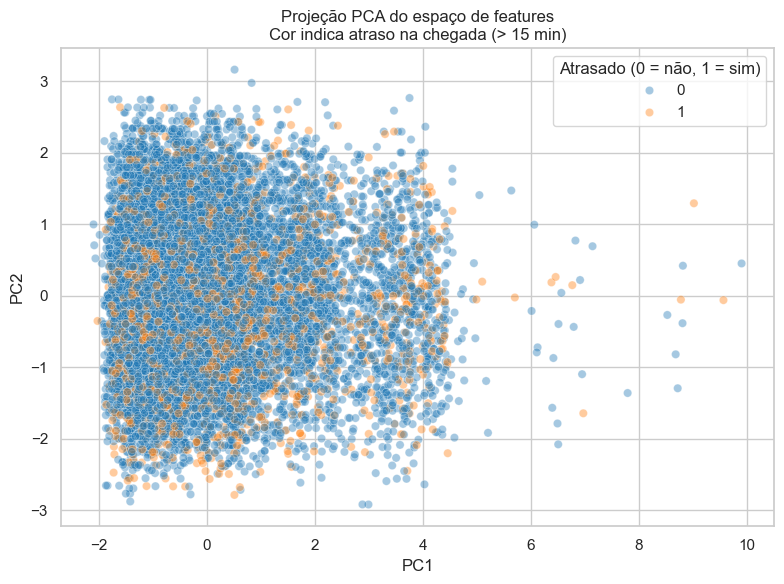

In [12]:
# Visualizar PCA em 2D, colorindo por atraso (0/1)

sample_for_plot = pca_sample.sample(n=min(15_000, len(pca_sample)), random_state=42)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sns.scatterplot(
    data=sample_for_plot,
    x="PC1",
    y="PC2",
    hue="atrasado",
    palette={0: "tab:blue", 1: "tab:orange"},
    alpha=0.4,
    ax=ax,
)

ax.set_title("Projeção PCA do espaço de features\nCor indica atraso na chegada (> 15 min)")
plt.legend(title="Atrasado (0 = não, 1 = sim)")
plt.tight_layout()
plt.show()

#### Interpretação dos resultados do PCA

Ao rodar as células de PCA, observe:

- **Variância explicada**:
  - Se os 2 primeiros componentes explicarem uma parte razoável da variância (ex.: > 40–50%), a projeção 2D já captura boa parte da estrutura dos dados.
  - Caso contrário, o espaço real pode ser mais complexo e exigir mais componentes.
- **Gráfico PC1 vs. PC2 colorido por `atrasado`**:
  - Se regiões específicas tiverem maior concentração de pontos `atrasado = 1`, isso sugere que certas combinações de mês, dia da semana, distância, duração e horário estão associadas a maior probabilidade de atraso.
  - Se `atrasado` estiver *muito misturado* em todo o gráfico, significa que **essas variáveis por si só não separam bem** os voos atrasados dos pontuais.

Mesmo sendo uma técnica **não supervisionada**, o rótulo `atrasado` é útil aqui apenas para **interpretar** como o espaço reduzido da PCA se relaciona com o fenômeno de atraso.

### Conclusões, limitações e próximos passos

**Principais conclusões (esperadas ao rodar o notebook):**

- **Clusterização de rotas (K-Means)** tende a separar grupos com perfis distintos, como:
  - rotas de **longa distância** operadas por poucas companhias e partindo de grandes hubs;
  - rotas de **curta/média distância**, mais pulverizadas em vários aeroportos;
  - possíveis grupos associados a **janelas de horário específicas** (picos da manhã/noite).
- **PCA** permite visualizar a distribuição dos voos em 2D, mostrando se há ou não regiões do espaço onde os atrasos se concentram.

**Limitações dos modelos não supervisionados usados:**

- O K-Means **assume clusters aproximadamente esféricos** e de tamanho similar; se os grupos reais forem muito irregulares, a clusterização pode ser enganosa.
- A escolha de `k` pelo método do cotovelo é **subjetiva** e pode variar conforme a amostra.
- PCA é uma transformação **linear**: relações não lineares entre variáveis (por exemplo, efeitos de horário + companhia de forma não linear) podem não ser bem capturadas.
- Usamos apenas um subconjunto de variáveis; outros fatores importantes (clima, aeroporto de conexão, histórico de atrasos, etc.) não estão incluídos.

**Possíveis melhorias e próximos passos:**

- Testar outros algoritmos de clusterização: **DBSCAN**, **Gaussian Mixture Models (GMM)**, ou **Agglomerative Clustering**, que podem capturar formatos de clusters mais complexos.
- Incluir mais variáveis (por exemplo, **dia do mês**, **causas de atraso**, características de aeroporto/companhia) para enriquecer o espaço de clusterização.
- Explorar **PCA com mais componentes** (3D, 4D) ou técnicas não lineares de redução de dimensionalidade, como **t-SNE** ou **UMAP**.
- Cruzar os clusters encontrados com a variável `atrasado` (ex.: proporção de atrasos por cluster) para identificar **grupos de rotas com maior risco de atraso**, o que pode alimentar ações operacionais ou modelos preditivos supervisionados.

Esse notebook complementa o modelo supervisionado ao fornecer **insights estruturais** sobre o espaço de rotas e características dos voos, mesmo sem usar o rótulo de atraso no processo de treinamento dos modelos.

### Exportar resultados para CSV

Nesta seção salvamos em CSV os principais resultados para exploração externa (por exemplo, em ferramentas de BI):

- **Amostra de voos com cluster de rota e coordenadas PCA de rota** (`routes_clusters_sample.csv`).
- **Resumo agregado por cluster de rota** (`routes_clusters_summary.csv`).
- **Amostra de voos com projeção PCA 2D e indicador de atraso** (`pca_voos_2d.csv`).

Os arquivos serão salvos por padrão na pasta `data/` (criada se ainda não existir).

In [14]:
# Exportar resultados de clusterização de rotas e PCA para CSV

output_dir = Path("data")
output_dir.mkdir(exist_ok=True)

# 1) Amostra de voos com cluster de rota e PCA (rotas)
#    Inclui companhia, aeroportos, distância, hora e PCs.
routes_cols_export = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "DISTANCE",
    "scheduled_dep_hour",
    "cluster",
    "PC1",
    "PC2",
]

routes_cols_export = [c for c in routes_cols_export if c in routes_plot.columns]

routes_plot[routes_cols_export].to_csv(output_dir / "routes_clusters_sample.csv", index=False)

# 2) Resumo agregado por cluster de rota
cluster_summary.to_csv(output_dir / "routes_clusters_summary.csv", index=True)

# 3) Amostra de voos com PCA 2D e indicador de atraso
pca_cols_export = [
    "YEAR",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "DISTANCE",
    "SCHEDULED_TIME",
    "scheduled_dep_hour",
    "ARRIVAL_DELAY",
    "atrasado",
    "PC1",
    "PC2",
]

pca_cols_export = [c for c in pca_cols_export if c in pca_sample.columns]

pca_sample[pca_cols_export].to_csv(output_dir / "pca_voos_2d.csv", index=False)

print("Arquivos salvos em:", output_dir.resolve())
print("- routes_clusters_sample.csv")
print("- routes_clusters_summary.csv")
print("- pca_voos_2d.csv")

Arquivos salvos em: /Users/kauan.silva/Desktop/TC3/data
- routes_clusters_sample.csv
- routes_clusters_summary.csv
- pca_voos_2d.csv
